<a href="https://colab.research.google.com/github/alperdinceler/Machine-learning/blob/main/gen%C3%A7li%C4%9Fe_hitabe_word2vec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
d0= "ATATÜRK’ÜN GENÇLİĞE HİTABESİ"
d1="Ey Türk gençliği! Birinci vazifen; Türk istiklalini, Türk cumhuriyetini, ilelebet muhafaza ve müdafaa etmektir."
d2="Mevcudiyetinin ve istikbalinin yegâne temeli budur."
d3="Bu temel, senin en kıymetli hazinendir."
d4="İstikbalde dahi seni bu hazineden mahrum etmek isteyecek dâhilî ve haricî bedhahların olacaktır."
d5="Bir gün, istiklal ve cumhuriyeti müdafaa mecburiyetine düşersen, vazifeye atılmak için içinde bulunacağın vaziyetin imkân ve şeraitini düşünmeyeceksin."
d6="Bu imkân ve şerait, çok namüsait bir mahiyette tezahür edebilir."
d7="İstiklal ve cumhuriyetine kastedecek düşmanlar, bütün dünyada emsali görülmemiş bir galibiyetin mümessili olabilirler."
d8="Cebren ve hile ile aziz vatanın bütün kaleleri zapt edilmiş, bütün tersanelerine girilmiş, bütün orduları dağıtılmış ve memleketin her köşesi bilfiil işgal edilmiş olabilir. Bütün bu şeraitten daha elim ve daha vahim olmak üzere, memleketin dâhilinde iktidara sahip olanlar, gaflet ve dalalet ve hatta hıyanet içinde bulunabilirler. Hatta bu iktidar sahipleri, şahsi menfaatlerini müstevlilerin siyasi emelleriyle tevhit edebilirler. Millet, fakruzaruret içinde harap ve bitap düşmüş olabilir.Ey Türk istikbalinin evladı! İşte, bu ahval ve şerait içinde dahi vazifen, Türk istiklal ve cumhuriyetini kurtarmaktır."
d9="Muhtaç olduğun kudret, damarlarındaki asil kanda mevcuttur."
d10="Mustafa Kemal Atatürk"
string=[d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10]

In [ ]:
import re

def tokenize(text):
    # Explicitly handle Turkish uppercase 'İ' and 'I' before lowercasing
    # Then normalize '’' to standard '''
    text = text.replace('İ', 'i').replace('I', 'ı').lower().replace('’', "'")

    # Split by whitespace first to handle spaces between words
    raw_words = text.split()

    cleaned_words = []
    # Pattern to find only valid word characters (including Turkish and apostrophe)
    # This ensures that punctuation attached to words is removed, and words are kept whole.
    word_char_pattern = re.compile(r"[a-zçğışöüâîû']+")

    for word in raw_words:
        # Extract valid word sequences from each raw word
        matches = word_char_pattern.findall(word)
        for match in matches:
            # Filter out single-character words (length > 1)
            if len(match) > 1:
                cleaned_words.append(match)
    return cleaned_words

tokenize_korpus = [tokenize(doc) for doc in string]
kelimeler = sorted(list(set([word for sublist in tokenize_korpus for word in sublist])))
kelime_idx = {w: i for i, w in enumerate(kelimeler)}
idx_kelime = {i: w for w, i in kelime_idx.items()}
V = len(kelimeler)

print(f"Kelime dağarcığı boyutu (V): {V}")
print(f"Kelimeler: {kelimeler}")

Kelime dağarcığı boyutu (V): 129
Kelimeler: ['ahval', 'asil', 'atatürk', "atatürk'ün", 'atılmak', 'aziz', 'bedhahların', 'bilfiil', 'bir', 'birinci', 'bitap', 'bu', 'budur', 'bulunabilirler', 'bulunacağın', 'bütün', 'cebren', 'cumhuriyeti', 'cumhuriyetine', 'cumhuriyetini', 'daha', 'dahi', 'dalalet', 'damarlarındaki', 'dağıtılmış', 'dâhilinde', 'dâhilî', 'dünyada', 'düşersen', 'düşmanlar', 'düşmüş', 'düşünmeyeceksin', 'edebilir', 'edebilirler', 'edilmiş', 'elim', 'emelleriyle', 'emsali', 'en', 'etmek', 'etmektir', 'evladı', 'ey', 'fakruzaruret', 'gaflet', 'galibiyetin', 'gençliğe', 'gençliği', 'girilmiş', 'görülmemiş', 'gün', 'harap', 'haricî', 'hatta', 'hazineden', 'hazinendir', 'her', 'hile', 'hitabesi', 'hıyanet', 'iktidar', 'iktidara', 'ile', 'ilelebet', 'imkân', 'isteyecek', 'istikbalde', 'istikbalinin', 'istiklal', 'istiklalini', 'için', 'içinde', 'işgal', 'işte', 'kaleleri', 'kanda', 'kastedecek', 'kemal', 'kudret', 'kurtarmaktır', 'köşesi', 'kıymetli', 'mahiyette', 'mahrum', 'm

In [ ]:
# Komşu (context) kelimeleri çıkarma
def get_context_pairs(tokenize_korpus, window_size=2):
    pairs = []
    for doc in tokenize_korpus:
        for i, hedef in enumerate(doc):
            # Pencere içindeki komşular
            bas = max(0, i - window_size)
            son = min(len(doc), i + window_size + 1)
            for j in range(bas, son):
                if i != j:
                    pairs.append((hedef, doc[j]))
    return pairs

context_pairs = get_context_pairs(tokenize_korpus, window_size=2)
print(f"Toplam (hedef, komşu) çifti: {len(context_pairs)}")
print("İlk 10 çift:")
for pair in context_pairs[:10]:
    print(f"  '{pair[0]}' -> '{pair[1]}'")

Toplam (hedef, komşu) çifti: 638
İlk 10 çift:
  'atatürk'ün' -> 'gençliğe'
  'atatürk'ün' -> 'hitabesi'
  'gençliğe' -> 'atatürk'ün'
  'gençliğe' -> 'hitabesi'
  'hitabesi' -> 'atatürk'ün'
  'hitabesi' -> 'gençliğe'
  'ey' -> 'türk'
  'ey' -> 'gençliği'
  'türk' -> 'ey'
  'türk' -> 'gençliği'


Birlikte Oluşum Matrisi (ilk 10 kelime):


,ahval,asil,atatürk,atatürk'ün,atılmak,aziz,bedhahların,bilfiil,bir,birinci
ahval,0,0,0,0,0,0,0,0,0,0
asil,0,0,0,0,0,0,0,0,0,0
atatürk,0,0,0,0,0,0,0,0,0,0
atatürk'ün,0,0,0,0,0,0,0,0,0,0
atılmak,0,0,0,0,0,0,0,0,0,0
aziz,0,0,0,0,0,0,0,0,0,0
bedhahların,0,0,0,0,0,0,0,0,0,0
bilfiil,0,0,0,0,0,0,0,0,0,0
bir,0,0,0,0,0,0,0,0,0,0
birinci,0,0,0,0,0,0,0,0,0,0


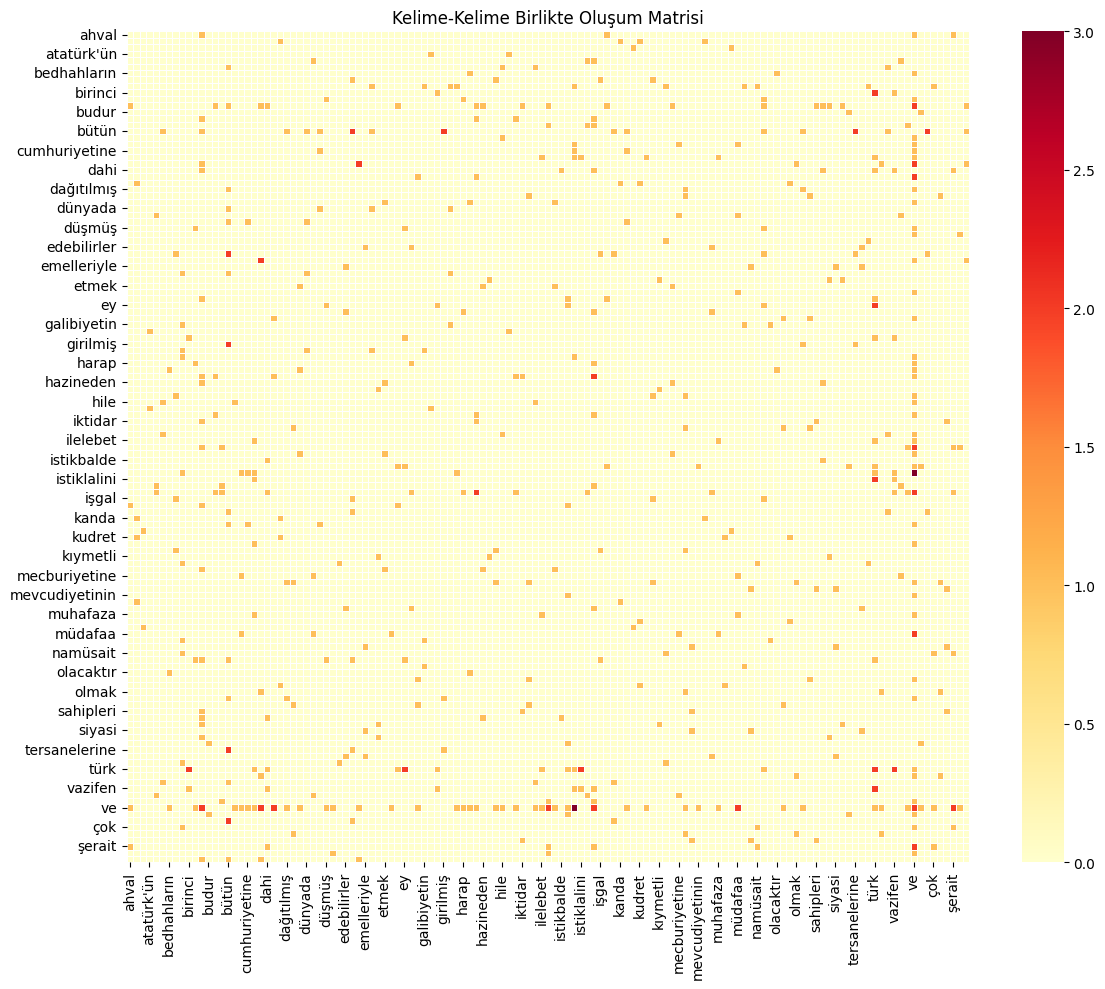

In [ ]:
# Birlikte oluşum matrisi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

cooc = np.zeros((V, V), dtype=int)
for hedef, komşu in context_pairs:
    i, j = kelime_idx[hedef], kelime_idx[komşu]
    cooc[i, j] += 1

df_cooc = pd.DataFrame(cooc, index=kelimeler, columns=kelimeler)
print("Birlikte Oluşum Matrisi (ilk 10 kelime):")
display(df_cooc.iloc[:10, :10])

# Görselleştirme: Isı haritası

plt.figure(figsize=(12, 10))
sns.heatmap(df_cooc, cmap="YlOrRd", annot=False if V < 15 else False, fmt="d", linewidths=0.5)
plt.title("Kelime-Kelime Birlikte Oluşum Matrisi")
plt.tight_layout()
plt.show()